# RandomForest

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
seed = 42

In [3]:
# dataset = pd.read_csv("./datasets/thyroid0387_cleanded.data", sep = ";", index_col="Unnamed: 0")
# dataset = pd.read_csv("./datasets/thyroid0387_imputed.data", sep = ";", index_col="Unnamed: 0")
dataset = pd.read_csv("./datasets/thyroid0387_balanced.data", sep = ";", index_col="Unnamed: 0")

In [4]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other,diagnosis_group
0,29.0,False,False,False,False,False,False,False,True,False,...,0.964407,110.901257,32.308245,False,False,False,False,False,True,normal
1,29.0,False,False,False,False,False,False,False,False,False,...,0.972645,133.325191,21.728779,False,False,False,False,False,True,normal
2,41.0,False,False,False,False,False,False,False,False,True,...,0.776130,122.989623,11.000000,False,False,False,False,False,True,normal
3,36.0,False,False,False,False,False,False,False,False,False,...,1.015283,107.444888,26.000000,False,False,False,False,False,True,normal
4,32.0,False,False,False,False,False,False,False,False,False,...,0.818433,120.404426,36.000000,False,False,False,False,False,True,misc


In [5]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
misc                     6446
hypothyroid              6446
hyperthyroid             6446
binding_protein          6446
replacement_therapy      6446
general_health           6446
antithyroid_treatment    6446
Name: count, dtype: int64

In [6]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [7]:
# x = dataset.drop(columns=["diagnosis_group", "diagnosis"])
x = dataset.drop(columns=["diagnosis_group"])
y = dataset["diagnosis_group"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [9]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (36097, 28)
X test: (15471, 28)
Y train: (36097,)
Y test: (15471,)


## Model

In [10]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

y_pred = rfc.predict(x_test)

## Model evaluation

Accuracy: 0.9986426216792709
F1 score: 0.9986418934472993


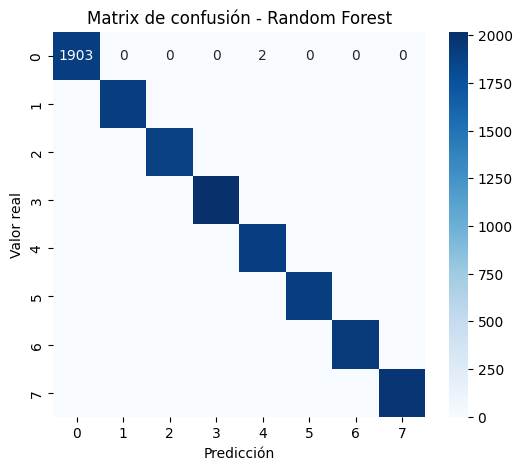

In [11]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - Random Forest')
plt.show()


## Saving model

In [12]:
joblib.dump(rfc, "./models_saved/randforest.json")

['./models_saved/randforest.json']

## Bayesian optimization

Function that will be used during the optimization

In [13]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),

        "random_state": seed,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [14]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-17 19:18:16,137] A new study created in memory with name: no-name-49c959c6-7050-4919-91bd-02f699823ceb
[I 2025-04-17 19:18:24,914] Trial 0 finished with value: 0.9986419272253723 and parameters: {'n_estimators': 219, 'max_depth': 17, 'min_samples_split': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9986419272253723.
[I 2025-04-17 19:18:31,976] Trial 1 finished with value: 0.9972865213524402 and parameters: {'n_estimators': 217, 'max_depth': 11, 'min_samples_split': 13, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9986419272253723.
[I 2025-04-17 19:18:37,860] Trial 2 finished with value: 0.9980608473469373 and parameters: {'n_estimators': 197, 'max_depth': 12, 'min_samples_split': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9986419272253723.
[I 2025-04-17 19:18:40,834] Trial 3 finished with value: 0.9980605079201248 and parameters: {'n_estimators': 99, 'max_depth': 12, 'min_samples_split': 4, 'max_features': 'sqrt'}. Best is trial 0 with v

In [15]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'n_estimators': 457, 'max_depth': 20, 'min_samples_split': 8, 'max_features': 'sqrt'}


In [16]:
rfc = RandomForestClassifier(**optimization.best_params)
rfc.fit(x_train, y_train)

y_pred = rfc.predict(x_test)

In [17]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.9987718958050547
F1 score: 0.9987714369186531


In [18]:
joblib.dump(rfc, "./models_saved/randforest_opt.json")

['./models_saved/randforest_opt.json']